<a href="https://colab.research.google.com/github/Bienbaz/Simple-Linear-Regression-Marketing-ROI-Analysis/blob/main/regression_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simple Linear Regression – Marketing ROI Analysis

Upload `marketing_and_sales_data_evaluate_lr.csv` when prompted and run all cells.

In [1]:
# ================================================
# Simple Linear Regression - Marketing ROI Analysis
# Copy and paste this entire code into Google Colab
# ================================================

# Step 1: Install required packages (if needed)
!pip install pandas seaborn statsmodels matplotlib scipy -q

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully!")

# Step 2: Upload the CSV file
from google.colab import files
print("📤 Please upload 'marketing_and_sales_data_evaluate_lr.csv'")
uploaded = files.upload()

# Load the dataset
import io
df = pd.read_csv(list(uploaded.keys())[0])
print("✅ Dataset loaded!")
print(f"Shape: {df.shape}")
df.head()

✅ Libraries imported successfully!
📤 Please upload 'marketing_and_sales_data_evaluate_lr.csv'


Saving marketing_and_sales_data_evaluate_lr.csv to marketing_and_sales_data_evaluate_lr.csv
✅ Dataset loaded!
Shape: (4572, 4)


,TV,Radio,Social_Media,Sales
0,16.0,6.566231,2.907983,54.732757
1,13.0,9.237765,2.409567,46.677897
2,41.0,15.886446,2.913410,150.177829
3,83.0,30.020028,6.922304,298.246340
4,15.0,8.437408,1.405998,56.594181


In [2]:
# Step 3: Explore the dataset
print("=== Dataset Info ===")
print(df.info())
print("\n=== Missing Values ===")
print(df.isna().sum())
print("\n=== Descriptive Statistics ===")
print(df.describe())

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4562 non-null   float64
 1   Radio         4568 non-null   float64
 2   Social_Media  4566 non-null   float64
 3   Sales         4566 non-null   float64
dtypes: float64(4)
memory usage: 143.0 KB
None

=== Missing Values ===
TV              10
Radio            4
Social_Media     6
Sales            6
dtype: int64

=== Descriptive Statistics ===
                TV        Radio  Social_Media        Sales
count  4562.000000  4568.000000   4566.000000  4566.000000
mean     54.066857    18.160356      3.323956   192.466602
std      26.125054     9.676958      2.212670    93.133092
min      10.000000     0.000684      0.000031    31.199409
25%      32.000000    10.525957      1.527849   112.322882
50%      53.000000    17.859513      3.055565   189.231172
75%      7

In [3]:
# Step 4: Handle missing values
# Drop rows where Sales (target) is missing
df_clean = df.dropna(subset=['Sales']).copy()

# For remaining missing values in predictors, we can drop or impute (here we drop for simplicity)
df_clean = df_clean.dropna()

print(f"Original shape: {df.shape}")
print(f"Cleaned shape: {df_clean.shape}")
print("Missing values after cleaning:")
print(df_clean.isna().sum())

Original shape: (4572, 4)
Cleaned shape: (4546, 4)
Missing values after cleaning:
TV              0
Radio           0
Social_Media    0
Sales           0
dtype: int64


<Figure size 1000x800 with 0 Axes>

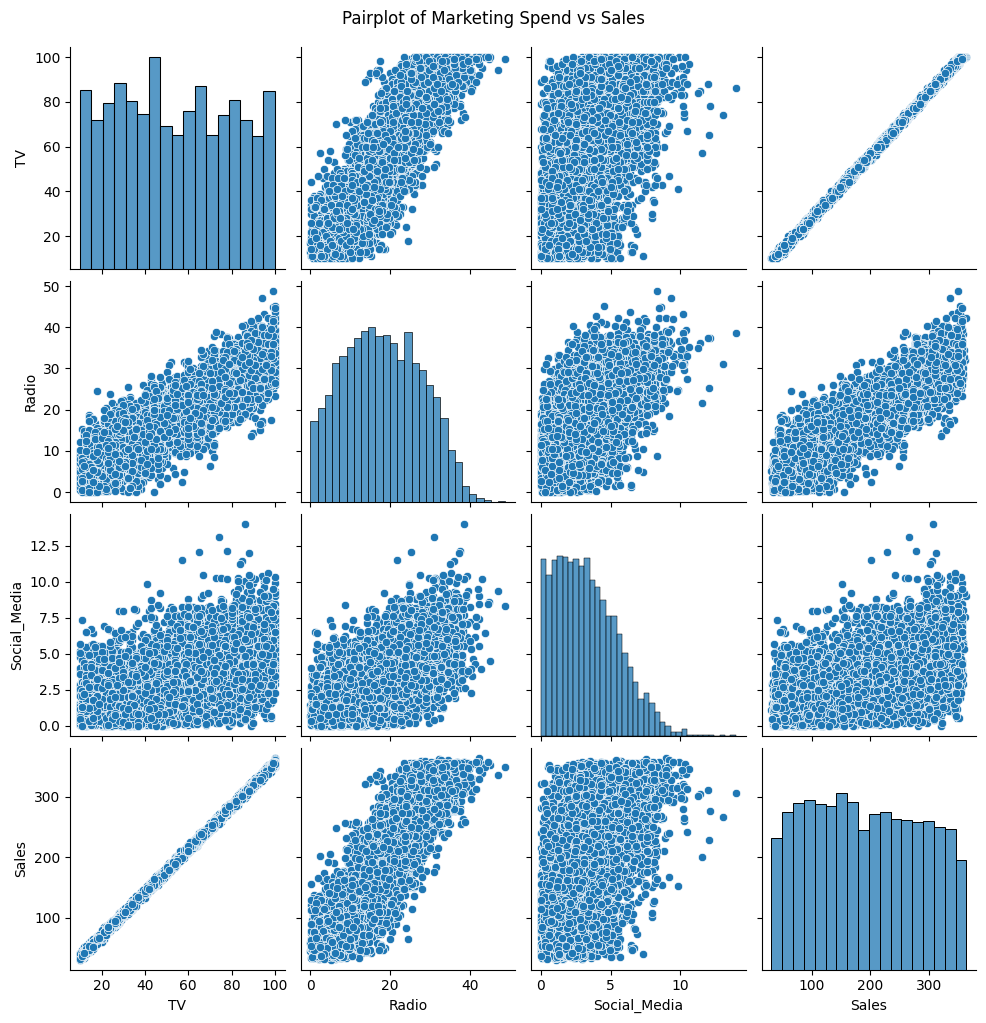

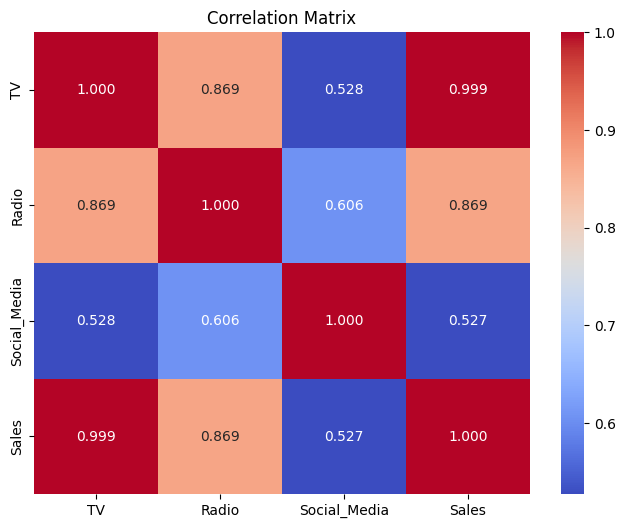

Correlations with Sales:
TV              0.999497
Radio           0.868638
Social_Media    0.527446
Name: Sales, dtype: float64


In [4]:
# Step 5: Exploratory Data Analysis (EDA)
# Pairplot to visualize relationships
plt.figure(figsize=(10, 8))
sns.pairplot(df_clean)
plt.suptitle("Pairplot of Marketing Spend vs Sales", y=1.02)
plt.show()

# Correlation matrix
plt.figure(figsize=(8, 6))
corr = df_clean.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.3f')
plt.title("Correlation Matrix")
plt.show()

# Identify the strongest predictor for Sales
correlations = df_clean.corr()['Sales'].drop('Sales').sort_values(ascending=False)
print("Correlations with Sales:")
print(correlations)

In [5]:
# Step 6: Build Simple Linear Regression Model (using TV as it's typically the strongest)
# Confirm strongest variable (usually TV)
best_predictor = correlations.index[0]
print(f"\n✅ Selected independent variable: {best_predictor}")

# Prepare data for OLS
ols_data = df_clean[[best_predictor, 'Sales']]

# Fit OLS model
model = ols(formula=f'Sales ~ {best_predictor}', data=ols_data).fit()

# Display model summary
print(model.summary())


✅ Selected independent variable: TV
                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.517e+06
Date:                Sun, 21 Jun 2026   Prob (F-statistic):               0.00
Time:                        12:23:08   Log-Likelihood:                -11366.
No. Observations:                4546   AIC:                         2.274e+04
Df Residuals:                    4544   BIC:                         2.275e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -

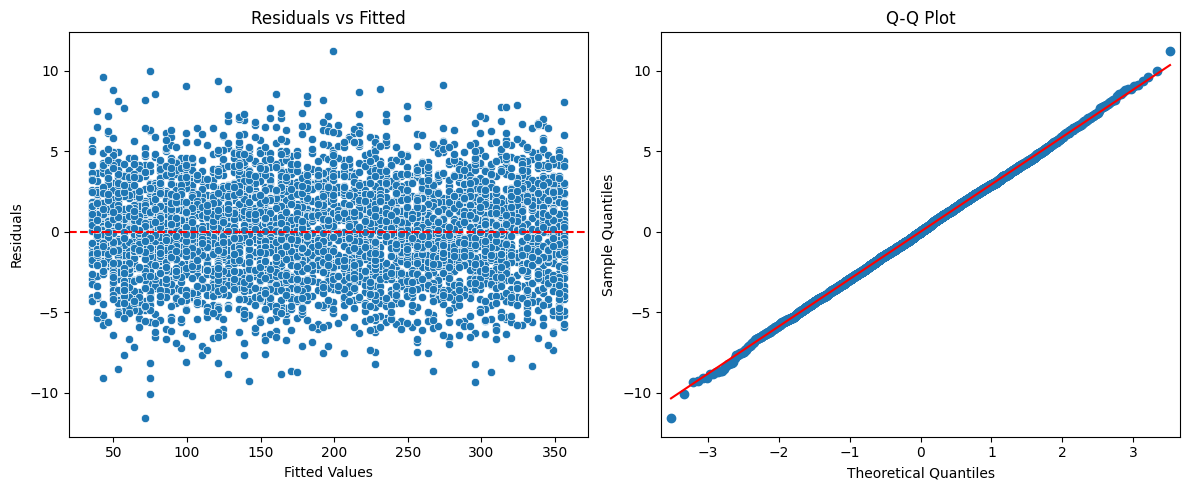

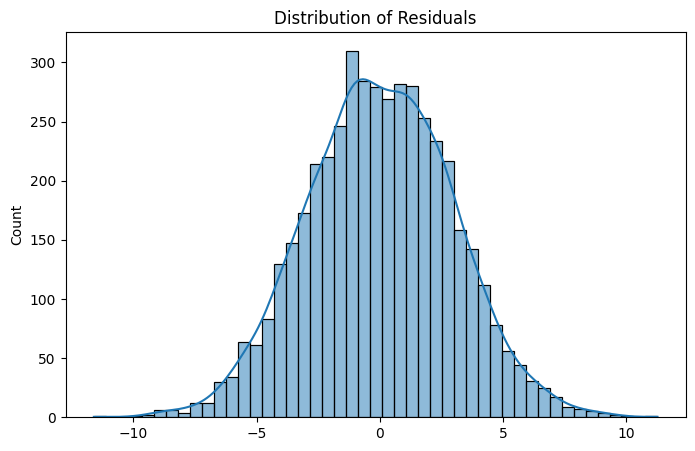

In [6]:
# Step 7: Diagnostic Plots
# 1. Residuals vs Fitted (Linearity & Homoscedasticity)
fitted = model.fittedvalues
residuals = model.resid

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(x=fitted, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted')

# 2. Q-Q Plot (Normality)
plt.subplot(1, 2, 2)
sm.qqplot(residuals, line='s', ax=plt.gca())
plt.title('Q-Q Plot')

plt.tight_layout()
plt.show()

# Additional: Histogram of residuals
plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True)
plt.title('Distribution of Residuals')
plt.show()

In [7]:
# Step 8: Interpretation and Business Insights
print("=== Model Interpretation ===")
print(f"R-squared: {model.rsquared:.4f} → {model.rsquared*100:.1f}% of variance in Sales explained by {best_predictor}")

coef = model.params[best_predictor]
intercept = model.params['Intercept']
pvalue = model.pvalues[best_predictor]

print(f"Coefficient for {best_predictor}: {coef:.4f}")
print(f"Intercept: {intercept:.4f}")
print(f"p-value: {pvalue:.4f} → {'Statistically significant' if pvalue < 0.05 else 'Not significant'}")

print("\n💡 Business Recommendation:")
print(f"For every $1M increase in {best_predictor} advertising spend,")
print(f"Sales are expected to increase by approximately ${coef:.2f}M.")
print("This channel shows the strongest ROI impact.")

=== Model Interpretation ===
R-squared: 0.9990 → 99.9% of variance in Sales explained by TV
Coefficient for TV: 3.5615
Intercept: -0.1325
p-value: 0.0000 → Statistically significant

💡 Business Recommendation:
For every $1M increase in TV advertising spend,
Sales are expected to increase by approximately $3.56M.
This channel shows the strongest ROI impact.


In [8]:
# Optional: Prediction example
def predict_sales(spend):
    return intercept + coef * spend

print("\nExample Predictions:")
for spend in [50, 100, 200]:
    print(f"${spend}M in {best_predictor} → Predicted Sales: ${predict_sales(spend):.2f}M")


Example Predictions:
$50M in TV → Predicted Sales: $177.94M
$100M in TV → Predicted Sales: $356.02M
$200M in TV → Predicted Sales: $712.17M
